In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path
import os
import time
import math
import json
from matplotlib.patches import Patch
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from scipy import stats
import torch.nn.functional as F
from ODE_BINN_fcts_nodgdu import *

device = "cuda" if torch.cuda.is_available() else "cpu"

In [53]:
def set_pubstyle(fontsize=10, font_family='serif', usetex=False):
    plt.rcParams.update({
        "font.size": fontsize,
        "font.family": font_family,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 1,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "figure.titlesize": fontsize + 2,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "lines.linewidth": 1.6,
        "axes.linewidth": 0.8,
        "grid.alpha": 0.2,
        "figure.figsize": (6.92, 4.2),
    })
    if usetex:
        plt.rcParams.update({"text.usetex": True})

# Call once globally for consistent style
set_pubstyle(fontsize=10, font_family='serif', usetex=False)

In [54]:
# Make datasets
out_root = "./synthetic_datasets_power"
os.makedirs(out_root, exist_ok=True)

models = {
    "Logistic": {
        "fn": fcts.logistic_analytic,
        "params": {"r": 0.08, "K": 10.0, "C0": 0.1}
    },
    "Gompertz": {
        "fn": fcts.gompertz_analytic,
        "params": {"r": 0.05, "K": 10.0, "C0": 0.1}
    },
    "Richards": {
        "fn": fcts.richards_analytic,
        "params": {"r": 0.06, "K": 10.0, "C0": 0.1, "beta": 2.0}
    }
}

# alphas and sigma0s to sweep
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]              # covers additive -> multiplicative
sigma0s = [0.01, 0.05, 0.1, 0.2, 0.5]            # base scales (interpretation depends on alpha)
R = 10                                           # replicates per dataset
seed_base = 1000   
t = np.linspace(0.0, 100.0, 26).astype(np.float32)

index = []  # summary entries

# ------------------------------
# Build datasets
# ------------------------------
for model_name, mdl in models.items():
    model_dir = os.path.join(out_root, model_name)
    os.makedirs(model_dir, exist_ok=True)
    fn = mdl["fn"]
    params = mdl["params"]

    # compute clean truth once per model
    C_true = fn(t, **params)

    for alpha in alphas:
        for sigma0 in sigma0s:
            # deterministic seed per (model,alpha,sigma0) for reproducibility
            seed = seed_base + int(round(1000 * alpha)) + int(round(10000 * sigma0))
            ds = BINNs.make_replicates_noise(t, C_true, R=R, sigma0=sigma0, alpha=alpha, mode="power", seed=seed, clip_min=0.0)

            # file naming
            fname = f"{model_name}_alpha_{alpha:.2f}_sigma0_{sigma0:.3f}_R{R}.npz"
            fpath = os.path.join(model_dir, fname)
            # save arrays and metadata
            # convert list of replicates to array (R, T)
            C_array = np.stack(ds["C_list"], axis=0)  # shape (R, T)
            np.savez_compressed(fpath,
                                t = t.astype(np.float32),
                                C_true = C_true.astype(np.float32),
                                C_reps = C_array.astype(np.float32),
                                alpha = float(alpha),
                                sigma0 = float(sigma0),
                                R = int(R),
                                model = model_name,
                                params = json.dumps(params))
            print("Saved:", fpath)

            # index entry
            index.append({
                "model": model_name,
                "file": os.path.relpath(fpath, out_root),
                "alpha": float(alpha),
                "sigma0": float(sigma0),
                "R": int(R),
                "seed": int(seed)
            })

# Save index file
with open(os.path.join(out_root, "index.json"), "w") as fh:
    json.dump(index, fh, indent=2)

print("Done. Datasets stored under:", out_root)

Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.010_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.050_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.100_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.200_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.500_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.010_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.050_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.100_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.200_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.25_sigma0_0.500_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.50_sigma0_0.010_R10.npz
Saved: ./synthetic_datasets_power/Logistic/Logistic_alpha_0.50_sigma0_0.050_

Saved preview to: ./paper_figs/preview_plots_3x5/Logistic_examples_3x5.png
Saved preview to: ./paper_figs/preview_plots_3x5/Gompertz_examples_3x5.png
Saved preview to: ./paper_figs/preview_plots_3x5/Richards_examples_3x5.png


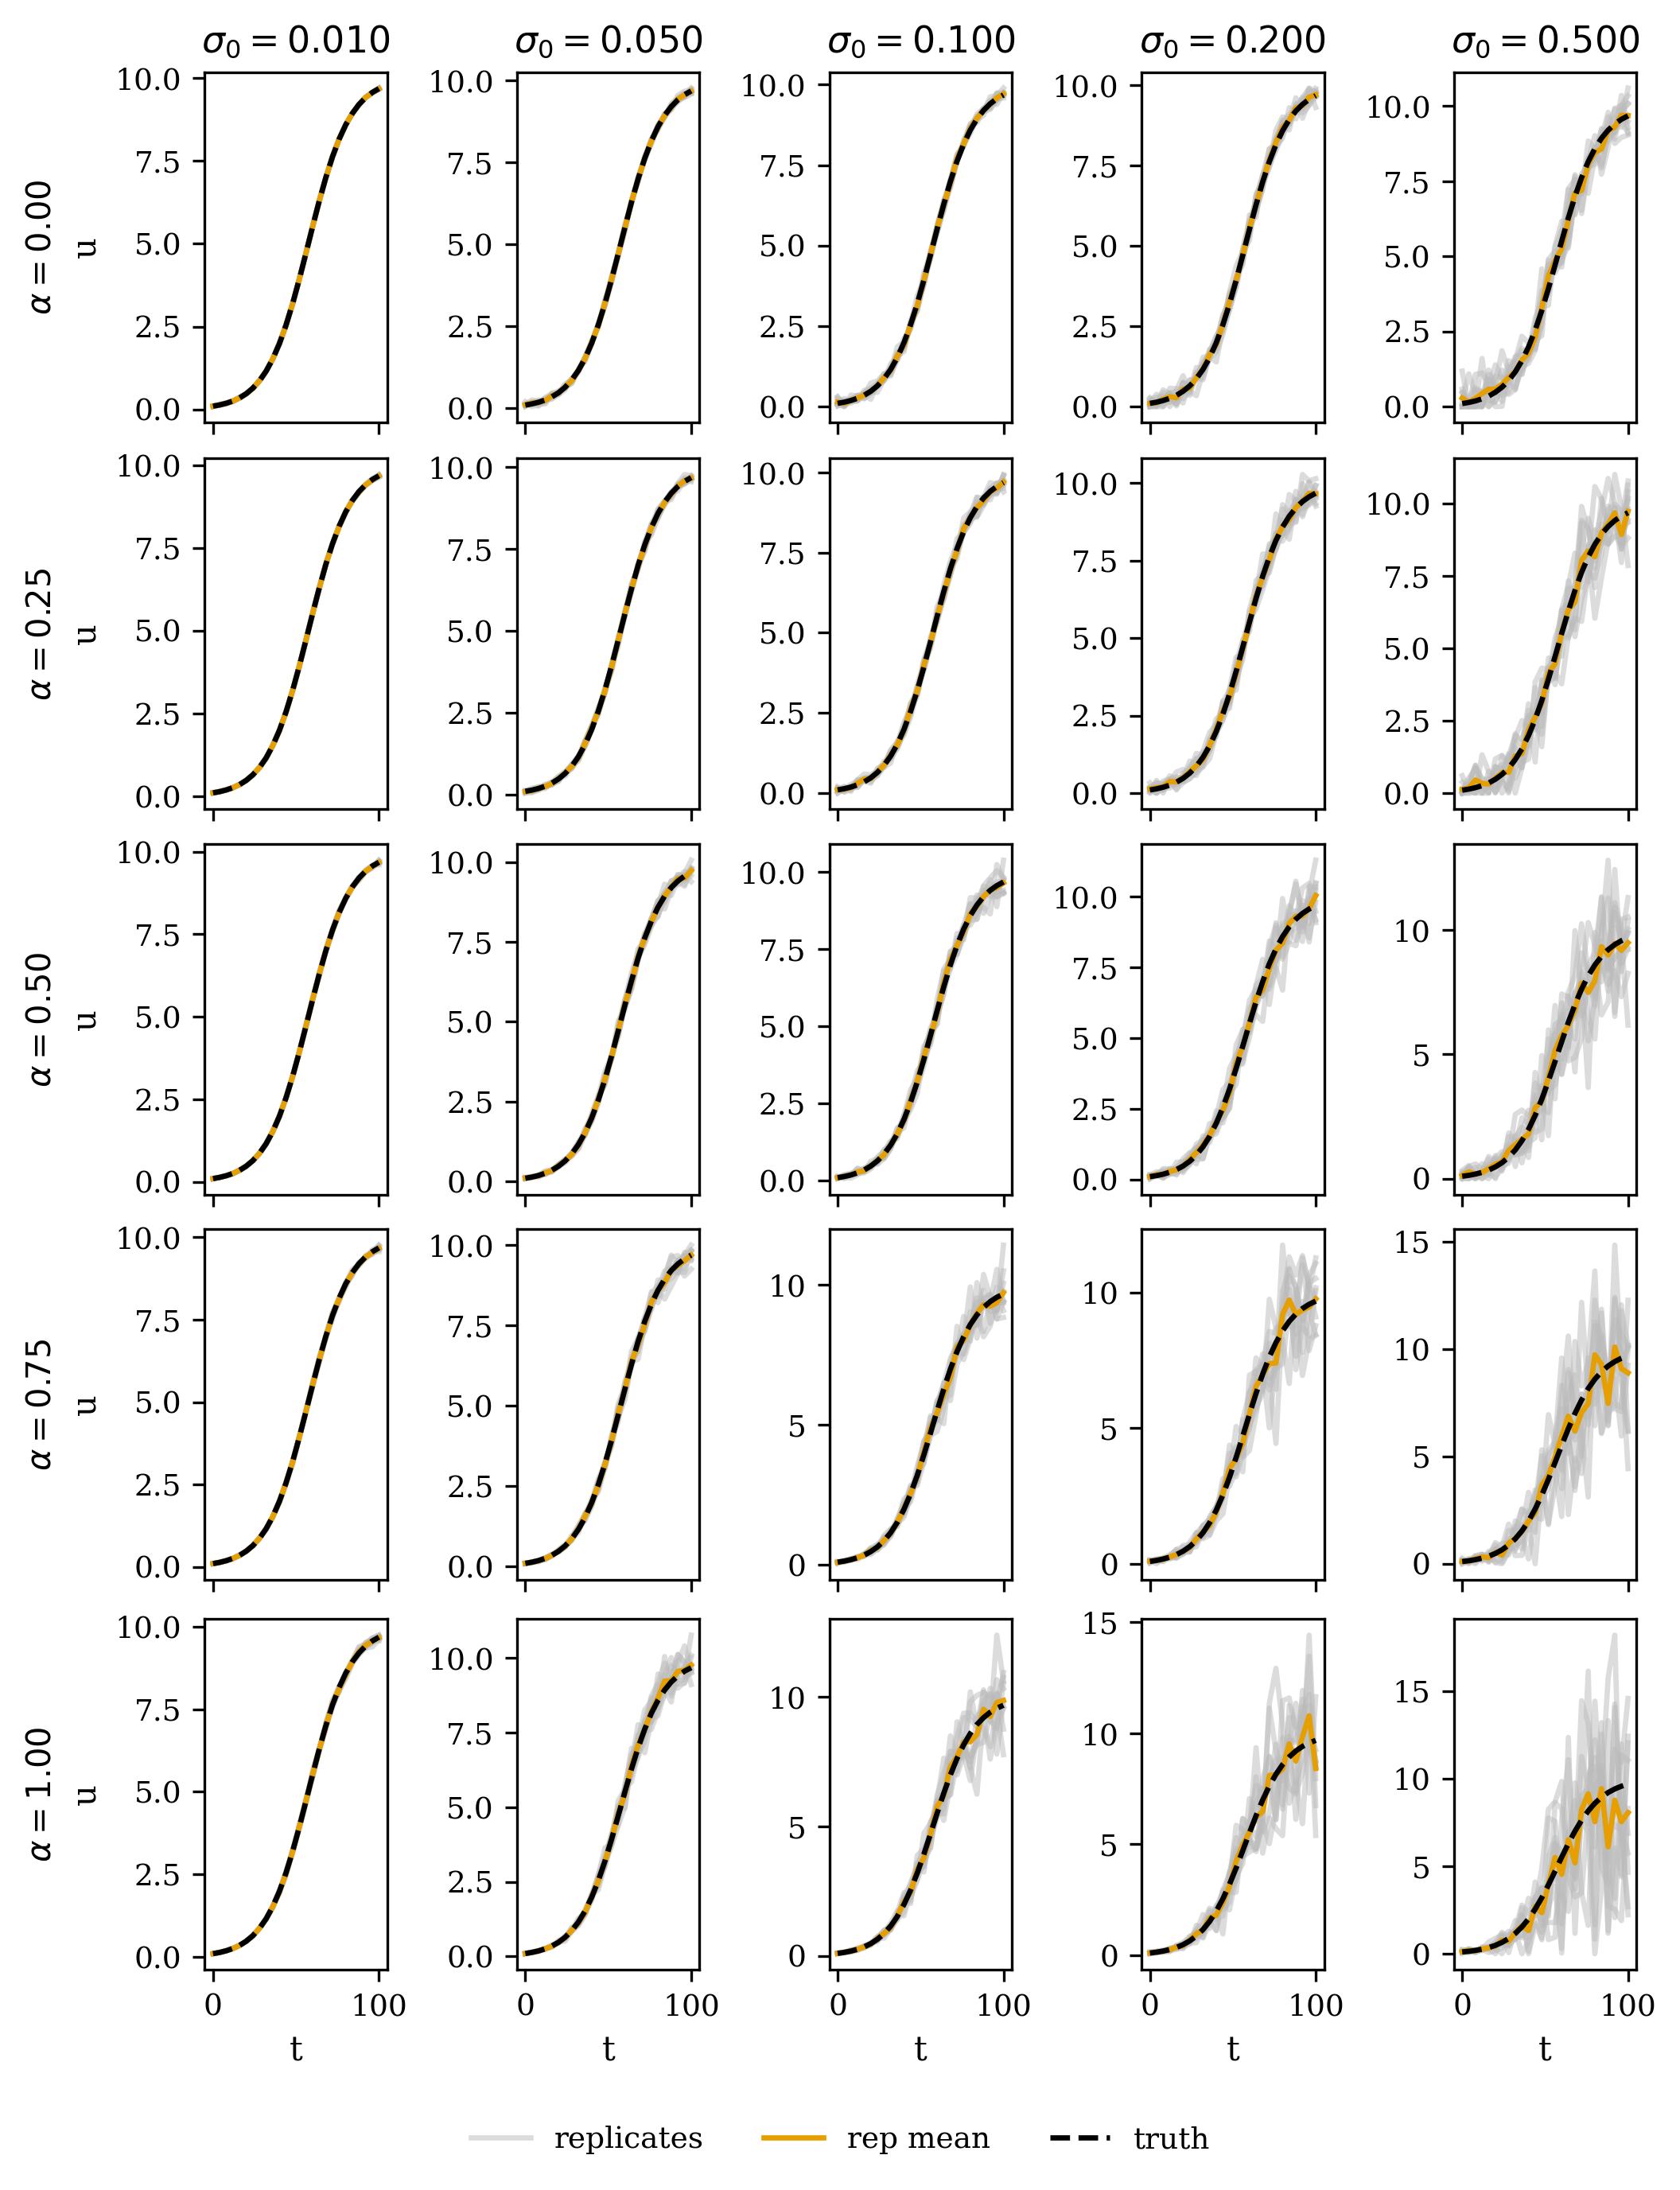

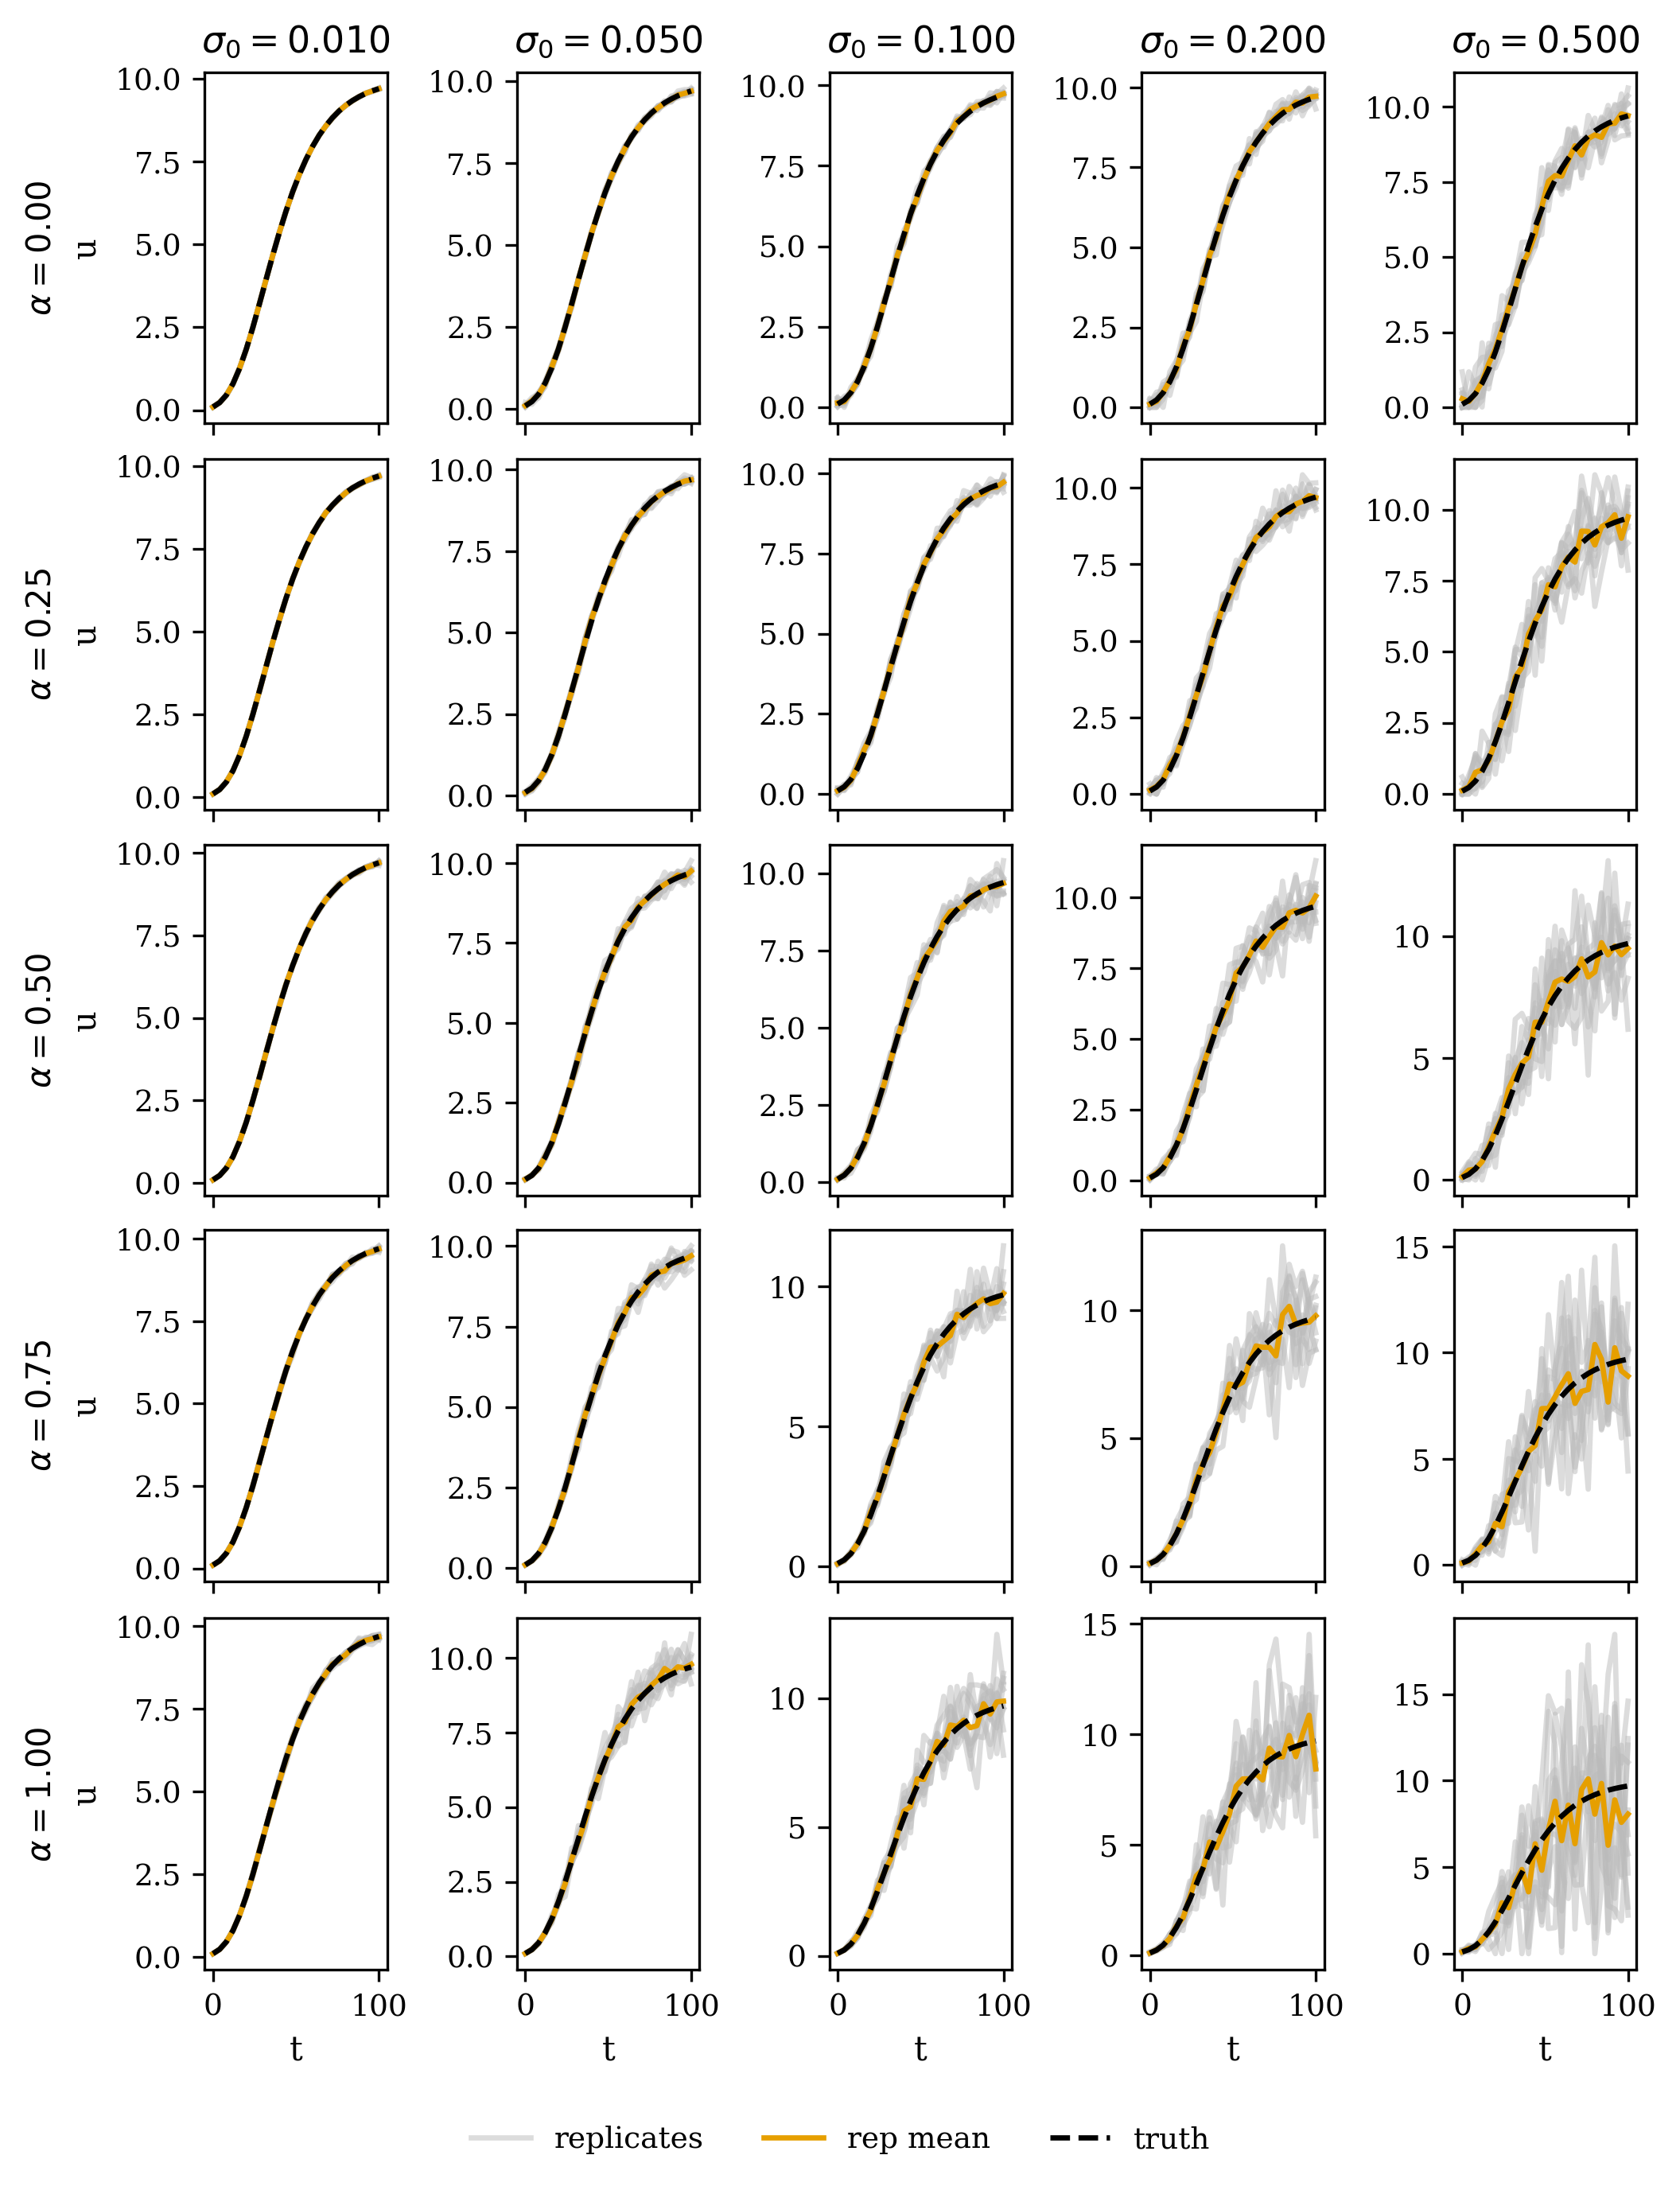

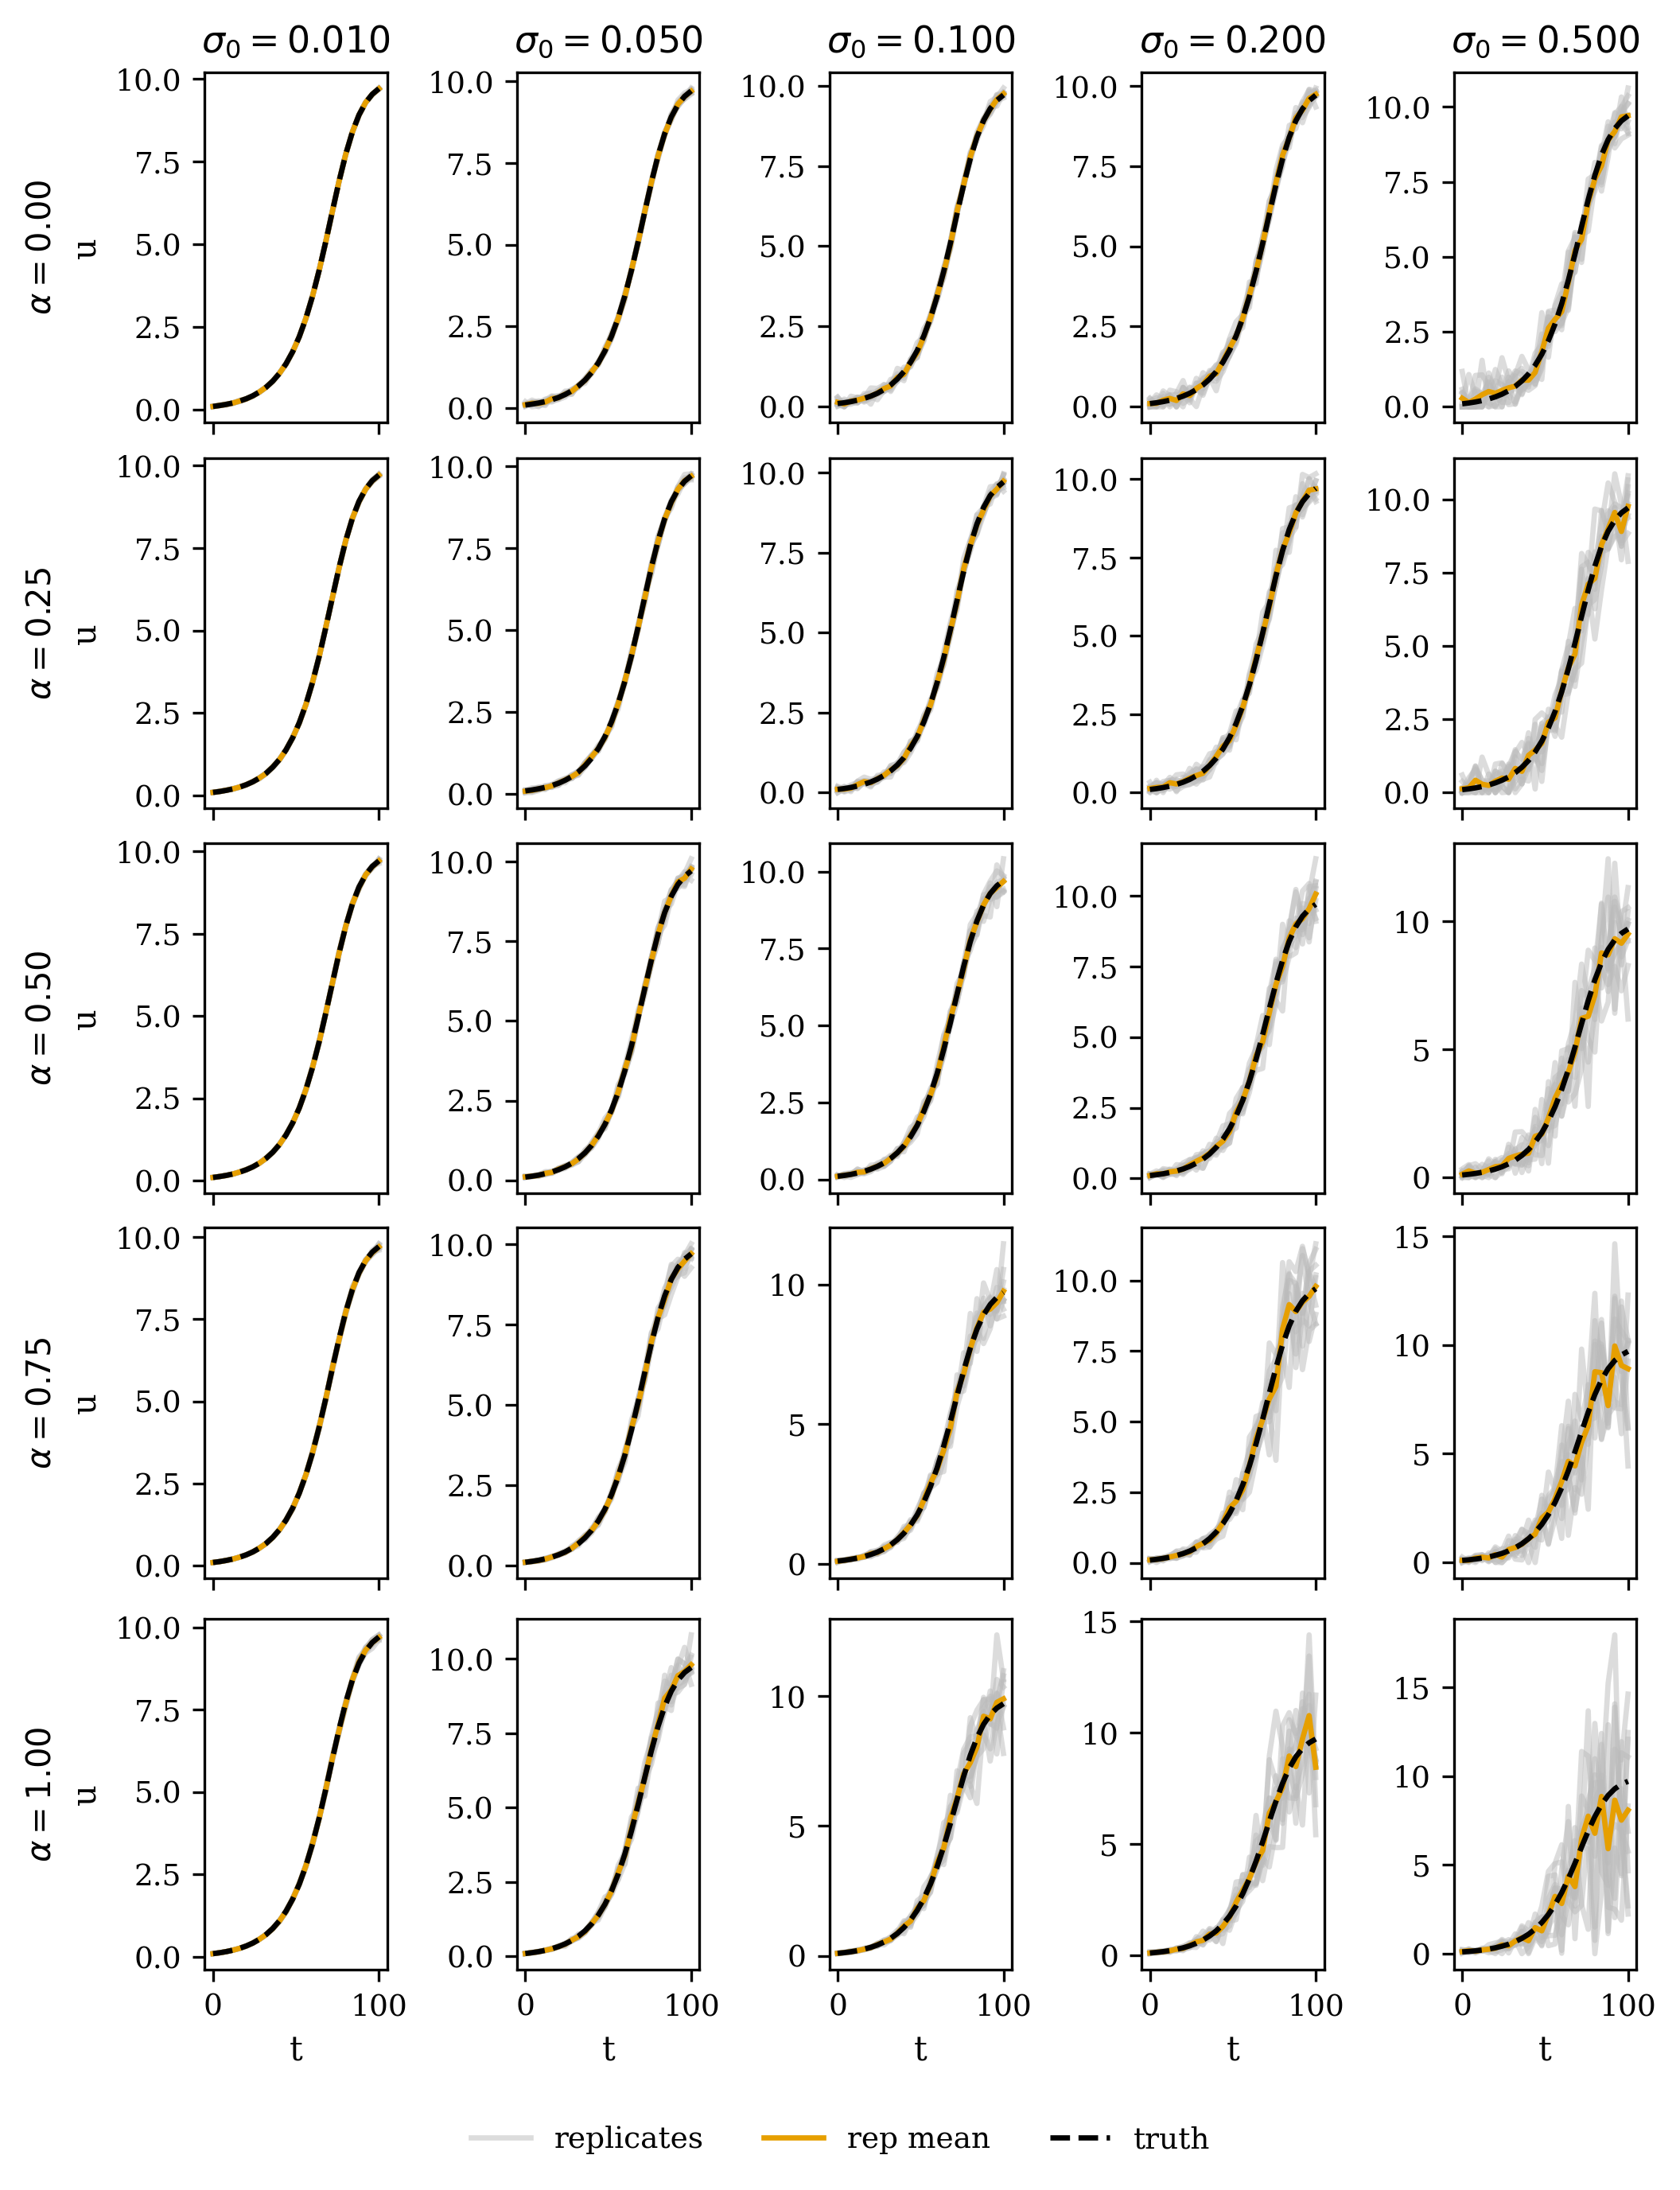

In [55]:
for model_name, mdl in models.items():
    fn = mdl["fn"]
    params = mdl["params"]
    C_true = fn(t, **params)
    fig, path = plotters.plot_example_data(model_name, C_true, t, alphas, sigma0s, R=R, seed=1)

In [56]:
data_a   = "./synthetic_datasets_power/Logistic/Logistic_alpha_0.00_sigma0_0.100_R10.npz"
data_mid = "./synthetic_datasets_power/Gompertz/Gompertz_alpha_0.50_sigma0_0.050_R10.npz"
data_m = "./synthetic_datasets_power/Richards/Richards_alpha_1.00_sigma0_0.200_R10.npz"
save_a = "./BINN_runs/Logistic_alpha0_sigma0_0.1"
save_mid = "./BINN_runs/Gompertz_alpha0.5_sigma0_0.05"
save_m = "./BINN_runs/Richards_alpha1_sigma0_0.2"

Numrep = 10

In [57]:
# to run the full training and save results, uncomment the following lines. This will take a while.
ens_power_a = BINNs.run_on_dataset_and_save(data_a, save_a, train_kwargs_override={"n_epochs":4000, "Numrep":Numrep})
ens_power_mid = BINNs.run_on_dataset_and_save(data_mid, save_mid, train_kwargs_override={"n_epochs":4000, "Numrep":Numrep})
ens_power_m = BINNs.run_on_dataset_and_save(data_m, save_m, train_kwargs_override={"n_epochs":4000, "Numrep":Numrep})

# if data is already saved, load the results instead of re-running training using the following lines:
ens_power_a = torch.load(os.path.join(save_a, "ensemble_full.pt"), map_location="cpu", weights_only=False)
ens_power_mid = torch.load(os.path.join(save_mid, "ensemble_full.pt"), map_location="cpu", weights_only=False)
ens_power_m = torch.load(os.path.join(save_m, "ensemble_full.pt"), map_location="cpu", weights_only=False)


Training finished and ensemble saved to BINN_runs/Logistic_alpha0_sigma0_0.1/ensemble_summary.npz
Training finished and ensemble saved to BINN_runs/Gompertz_alpha0.5_sigma0_0.05/ensemble_summary.npz
Training finished and ensemble saved to BINN_runs/Richards_alpha1_sigma0_0.2/ensemble_summary.npz


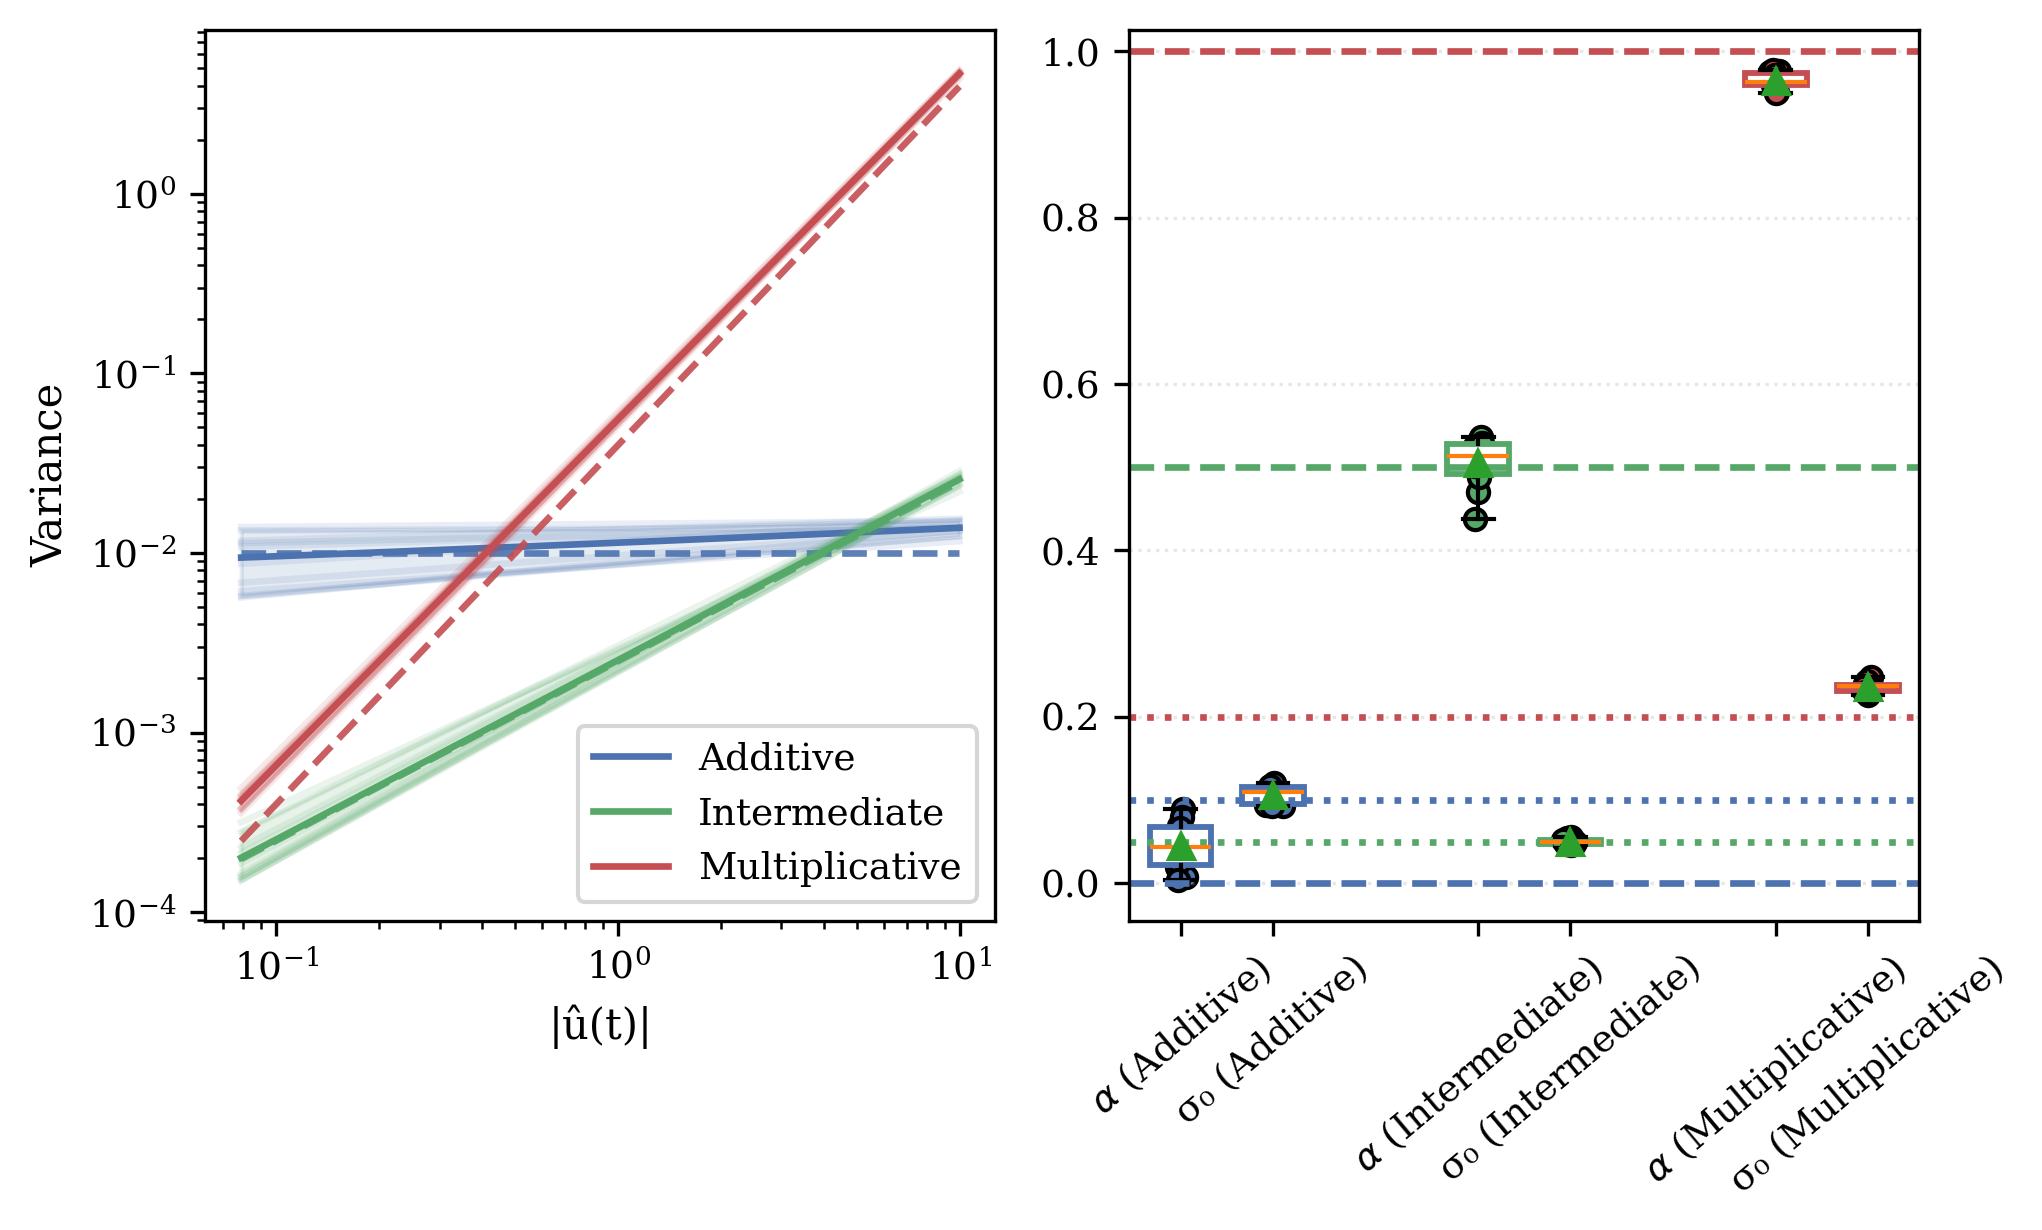

In [58]:
COLS = ["#4C72B0", "#55A868", "#C44E52"]

expA = {"label":"Additive","ens":ens_power_a,"save_dir":save_a,"sigma_true":0.1,"beta_true":0,"color":COLS[0]}
expB = {"label":"Intermediate","ens":ens_power_mid,"save_dir":save_mid,"sigma_true":0.05,"beta_true":0.5,"color":COLS[1]}
expC = {"label":"Multiplicative","ens":ens_power_m,"save_dir":save_m,"sigma_true":0.2,"beta_true":1,"color":COLS[2]}

fig, details = plotters.compare_many_experiments([expA, expB, expC], Numrep=Numrep, device="cpu")

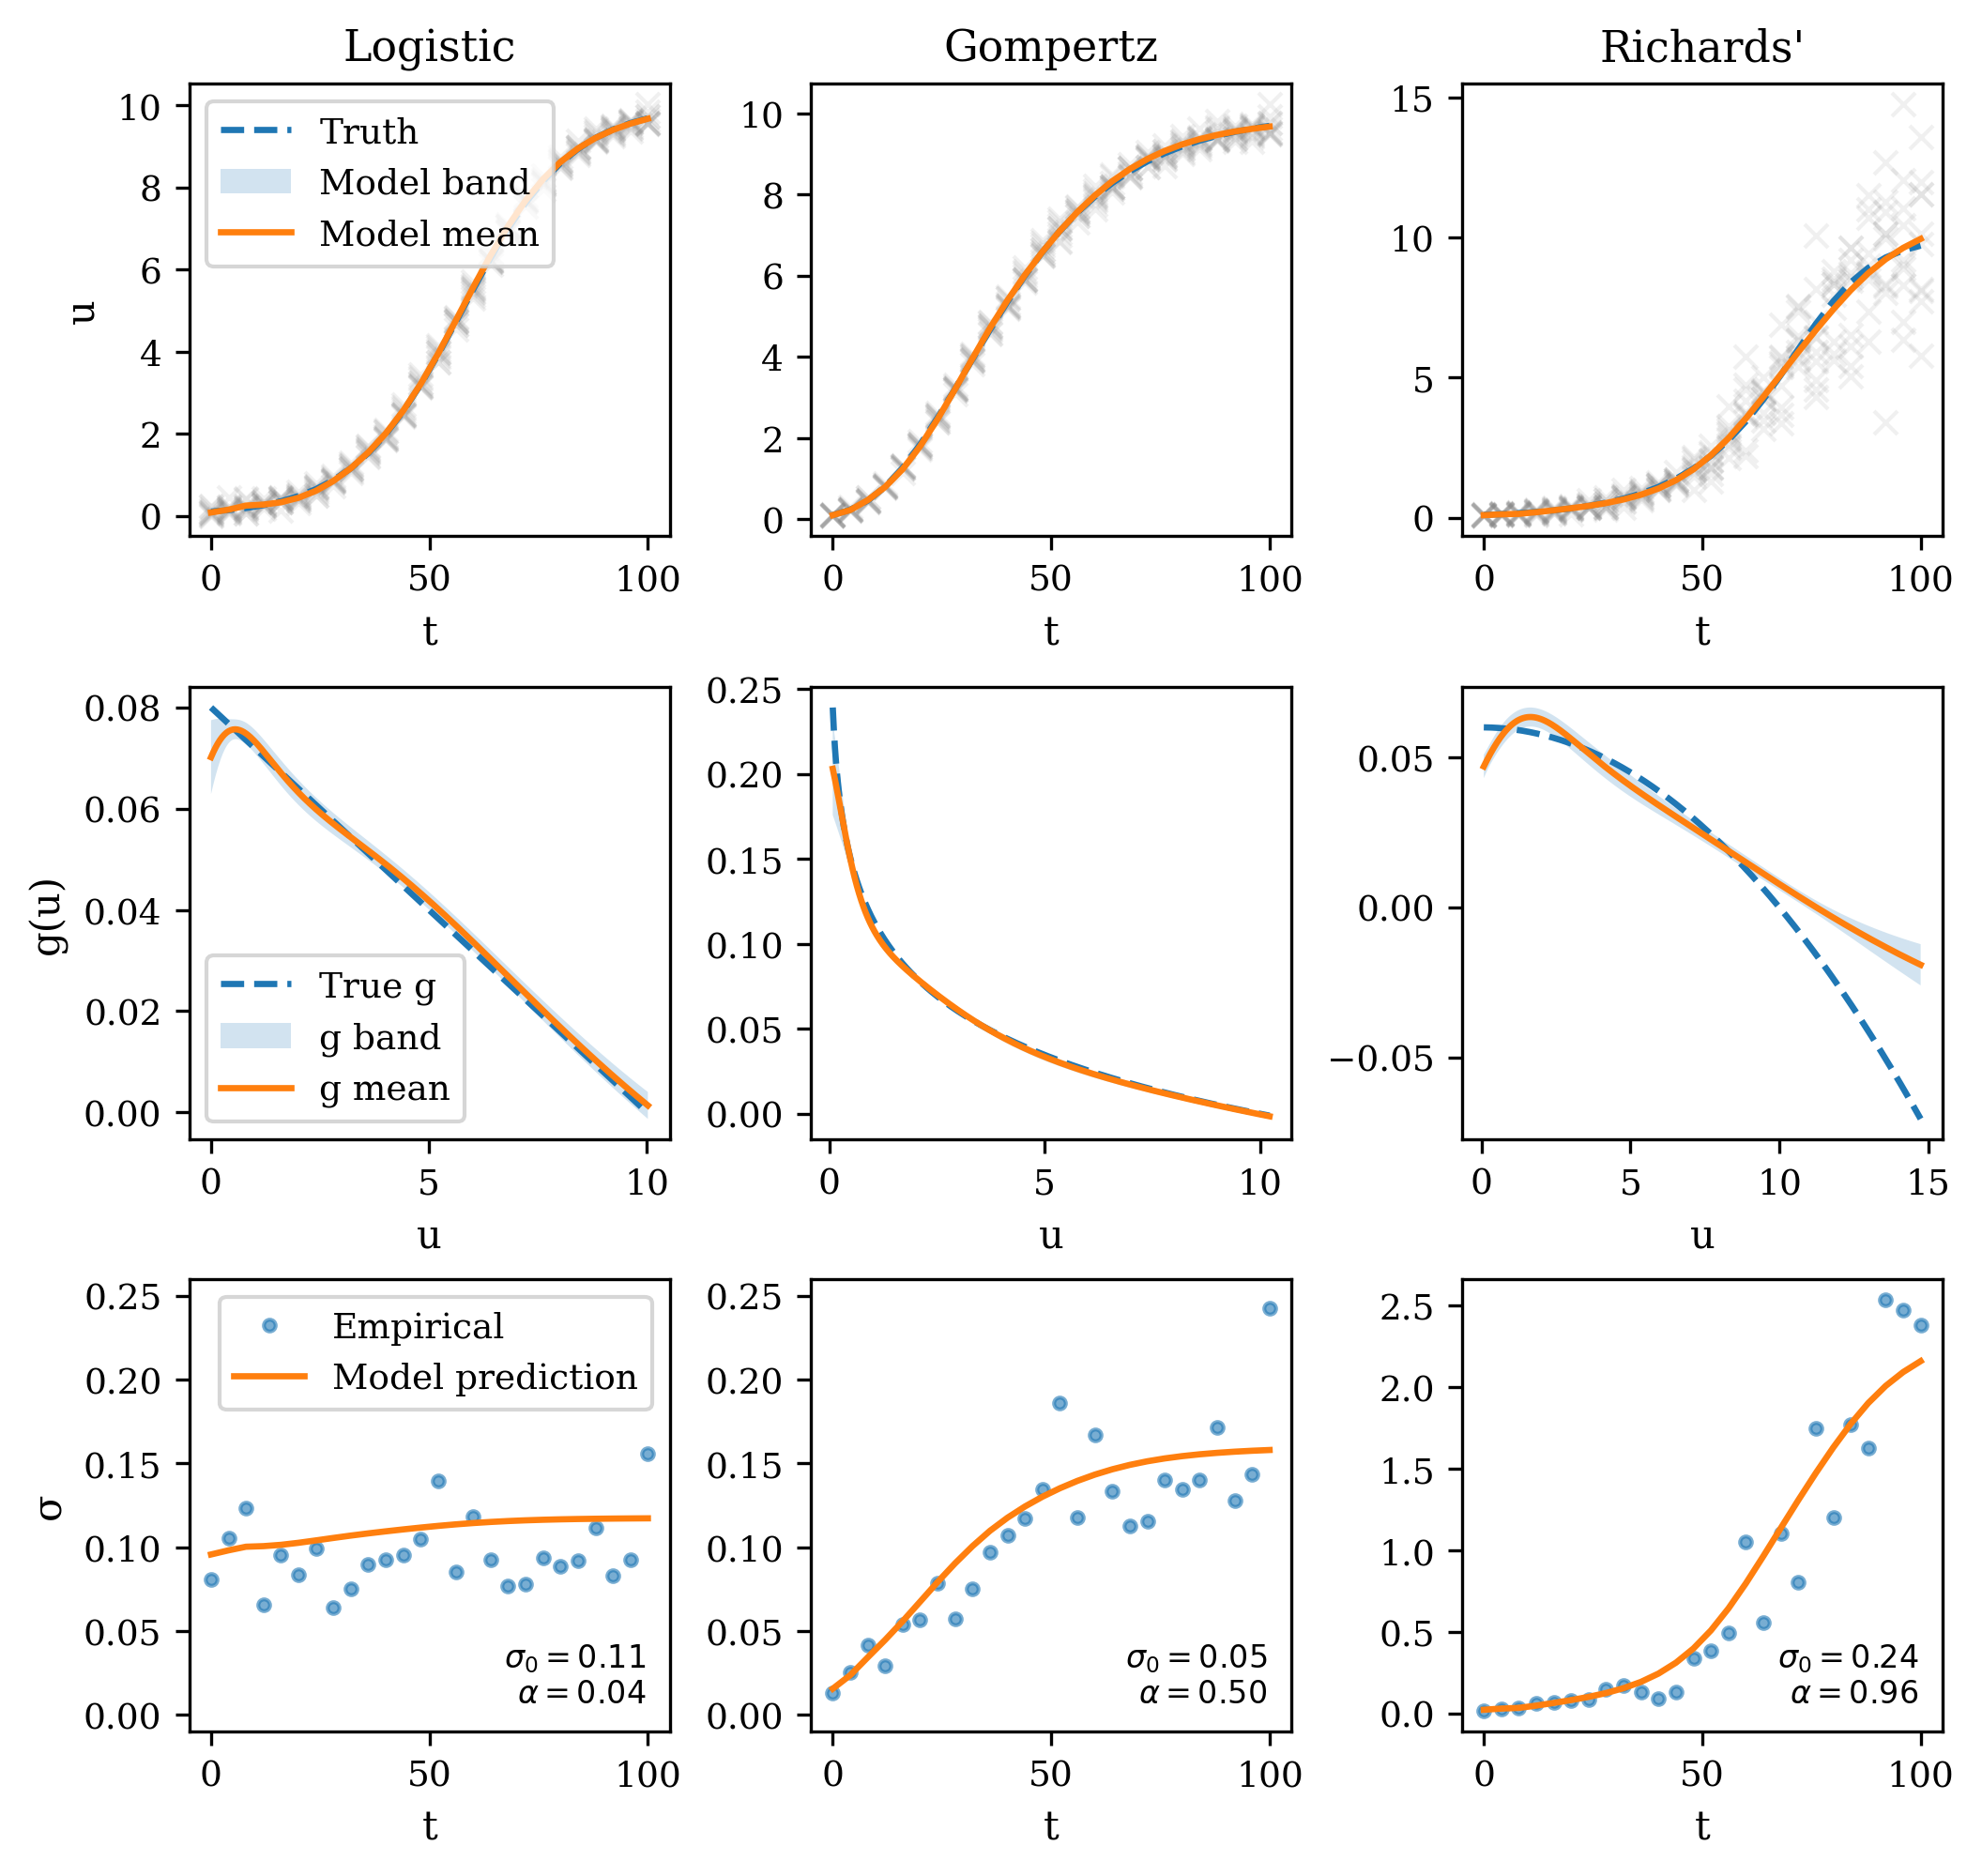

In [59]:
fig = plotters.plot_3x3_with_noise_BINN(
    [ens_power_a, ens_power_mid, ens_power_m],
    names=["Logistic","Gompertz","Richards'"]
)

plt.show()

rep 01: frac±1σ = 0.769, ±2σ = 1.000
rep 02: frac±1σ = 0.846, ±2σ = 0.962
rep 03: frac±1σ = 0.615, ±2σ = 0.962
rep 04: frac±1σ = 0.615, ±2σ = 1.000
rep 05: frac±1σ = 0.692, ±2σ = 0.923
rep 06: frac±1σ = 0.885, ±2σ = 0.962
rep 07: frac±1σ = 0.731, ±2σ = 1.000
rep 08: frac±1σ = 0.692, ±2σ = 0.962
rep 09: frac±1σ = 0.808, ±2σ = 0.962
rep 10: frac±1σ = 0.615, ±2σ = 0.923
rep 01: frac±1σ = 0.538, ±2σ = 0.962
rep 02: frac±1σ = 0.654, ±2σ = 0.923
rep 03: frac±1σ = 0.500, ±2σ = 0.962
rep 04: frac±1σ = 0.577, ±2σ = 1.000
rep 05: frac±1σ = 0.577, ±2σ = 0.846
rep 06: frac±1σ = 0.808, ±2σ = 0.962
rep 07: frac±1σ = 0.692, ±2σ = 1.000
rep 08: frac±1σ = 0.692, ±2σ = 0.923
rep 09: frac±1σ = 0.808, ±2σ = 1.000
rep 10: frac±1σ = 0.654, ±2σ = 1.000
rep 01: frac±1σ = 0.885, ±2σ = 1.000
rep 02: frac±1σ = 0.692, ±2σ = 1.000
rep 03: frac±1σ = 0.654, ±2σ = 1.000
rep 04: frac±1σ = 0.692, ±2σ = 0.962
rep 05: frac±1σ = 0.731, ±2σ = 0.885
rep 06: frac±1σ = 0.846, ±2σ = 0.962
rep 07: frac±1σ = 0.654, ±2σ = 1.000
r

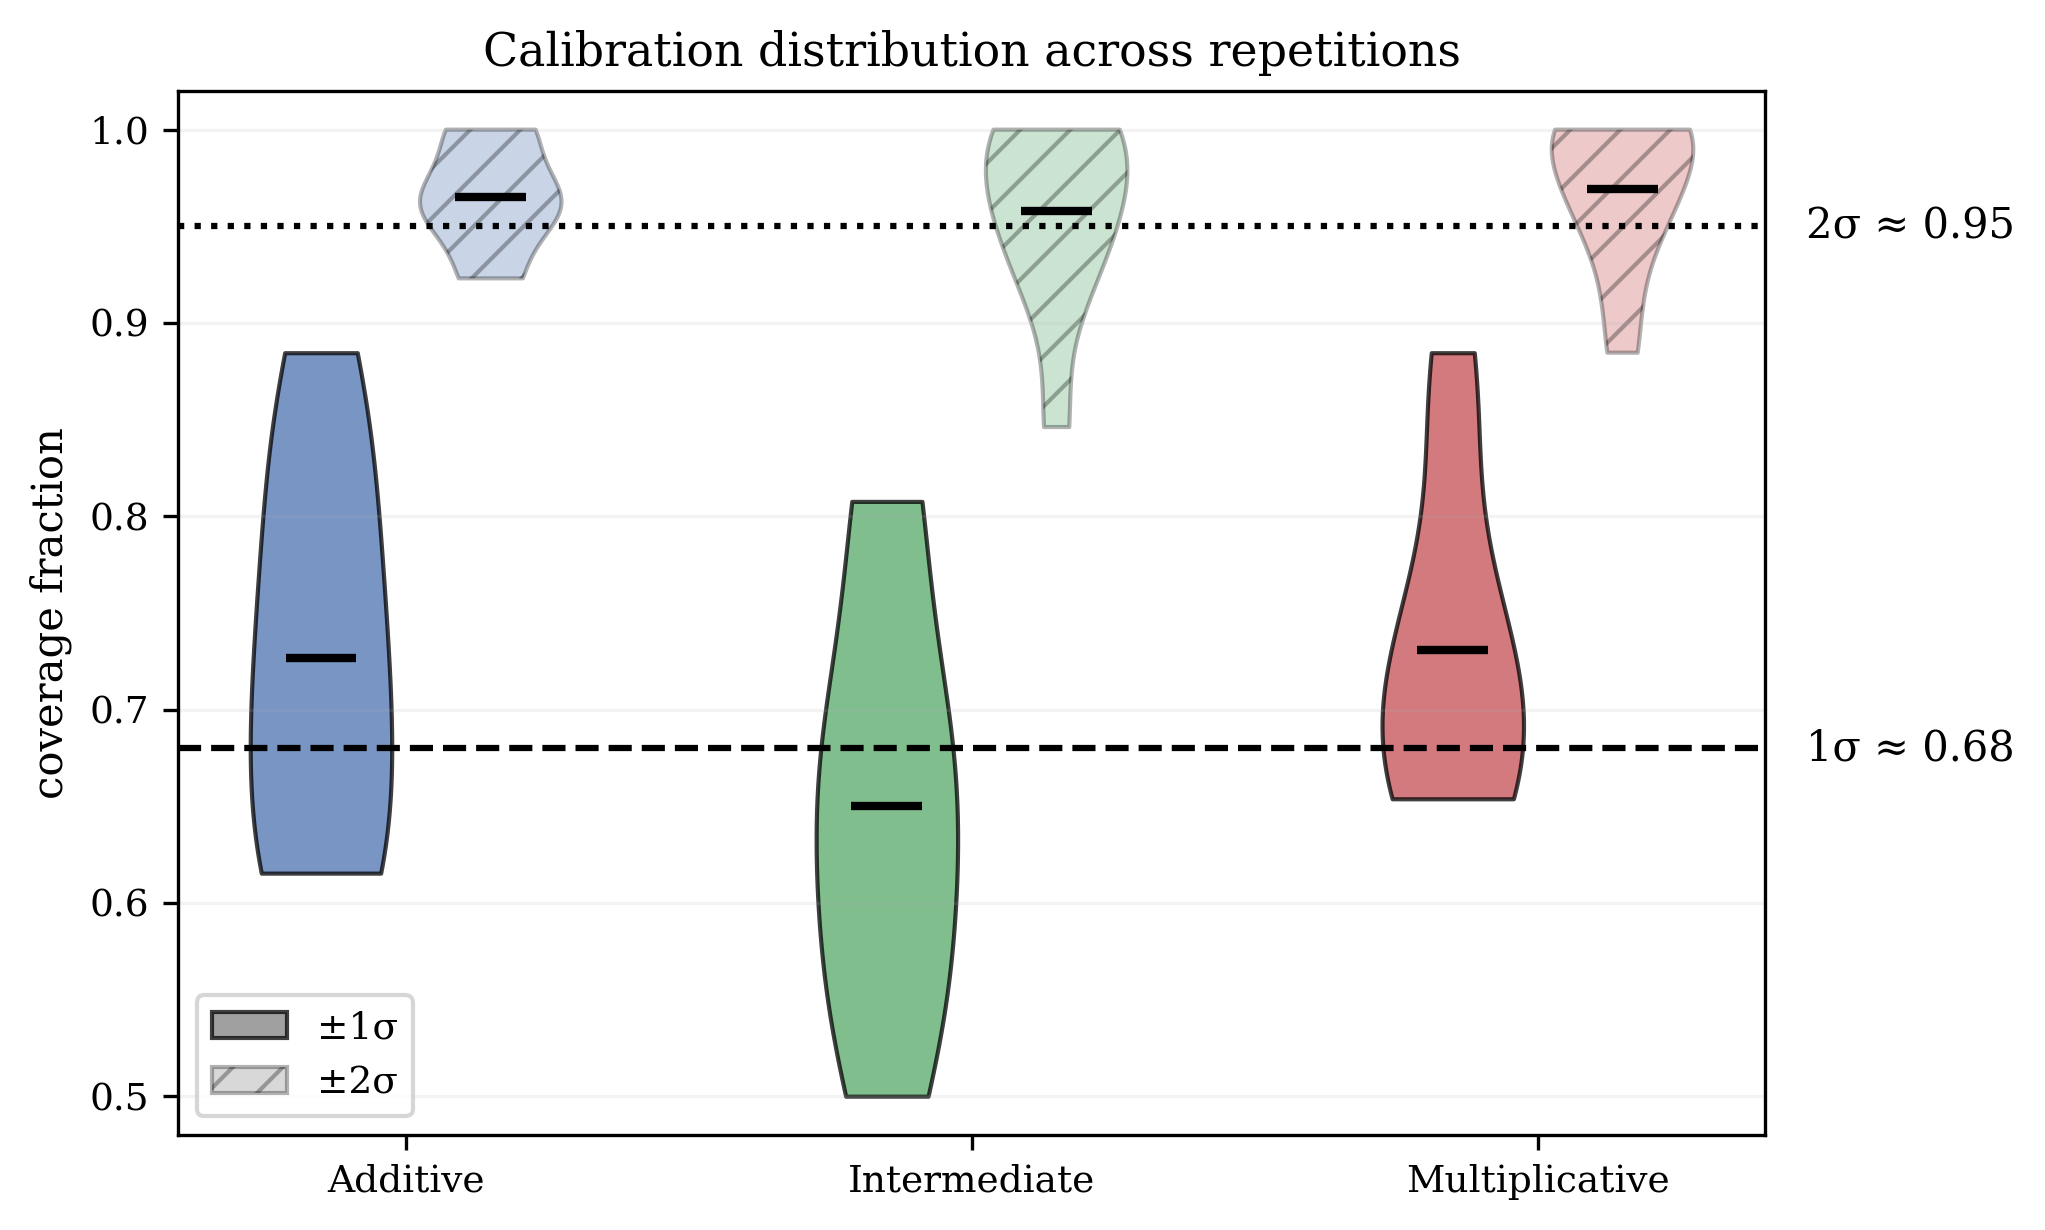

In [60]:
cal_a = BINNs.recompute_calibration_from_artifacts(save_a, data_a, Numrep=Numrep, device=device)
cal_mid = BINNs.recompute_calibration_from_artifacts(save_mid, data_mid, Numrep=Numrep, device=device)
cal_m = BINNs.recompute_calibration_from_artifacts(save_m, data_m, Numrep=Numrep, device=device)

labels = [expA["label"], expB["label"], expC["label"]]

data1 = [
    np.asarray(cal_a["1sigma"], dtype=float),
    np.asarray(cal_mid["1sigma"], dtype=float),
    np.asarray(cal_m["1sigma"], dtype=float),
]

data2 = [
    np.asarray(cal_a["2sigma"], dtype=float),
    np.asarray(cal_mid["2sigma"], dtype=float),
    np.asarray(cal_m["2sigma"], dtype=float),
]

fig, ax = plt.subplots()

n = len(labels)
pos1 = np.arange(n) * 2.0
pos2 = pos1 + 0.6
width = 0.5

COLS = ["#4C72B0", "#55A868", "#C44E52"]

# ±1σ violins
parts1 = ax.violinplot(data1, positions=pos1, widths=width,
                       showmeans=True, showextrema=False)

# ±2σ violins
parts2 = ax.violinplot(data2, positions=pos2, widths=width,
                       showmeans=True, showextrema=False)

# Style violins
for i, body in enumerate(parts1['bodies']):
    body.set_facecolor(COLS[i])
    body.set_edgecolor('black')
    body.set_alpha(0.75)

for i, body in enumerate(parts2['bodies']):
    body.set_facecolor(COLS[i])
    body.set_edgecolor('black')
    body.set_alpha(0.30)
    body.set_hatch('//')   # visually differentiate 2σ

# Style mean lines
parts1['cmeans'].set_color('black')
parts1['cmeans'].set_linewidth(2)

parts2['cmeans'].set_color('black')
parts2['cmeans'].set_linewidth(2)

# Ideal lines (stronger + labeled)
ax.axhline(0.68, color='black', linestyle='--', linewidth=1.5)
ax.axhline(0.95, color='black', linestyle=':', linewidth=1.5)

ax.text(pos1[-1]+1.25, 0.68, "1σ ≈ 0.68", va='center')
ax.text(pos1[-1]+1.25, 0.95, "2σ ≈ 0.95", va='center')

# Formatting
ax.set_xticks(pos1 + 0.3)
ax.set_xticklabels(labels)
ax.set_ylim(0.48, 1.02)
ax.set_ylabel("coverage fraction")
ax.set_title("Calibration distribution across repetitions")

ax.grid(axis='y', alpha=0.15)

# Custom legend
legend_elements = [
    Patch(facecolor='gray', edgecolor='black', alpha=0.75, label='±1σ'),
    Patch(facecolor='gray', edgecolor='black', alpha=0.30, hatch='//', label='±2σ'),
]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.show()

In [61]:
Numrep = 20

save_dir_rmse_log  = "./runs/logistic_rmse"   
save_dir_nll_log   = "./runs/logistic_nll"    
save_dir_rmse_gom  = "./runs/gompertz_rmse"
save_dir_nll_gom   = "./runs/gompertz_nll"
save_dir_rmse_rich = "./runs/richards_rmse"
save_dir_nll_rich  = "./runs/richards_nll"

In [62]:
npz_log = "./synthetic_datasets_power/Logistic/Logistic_alpha_1.00_sigma0_0.200_R10.npz"
npz_gom = "./synthetic_datasets_power/Gompertz/Gompertz_alpha_1.00_sigma0_0.200_R10.npz"
npz_rich = "./synthetic_datasets_power/Richards/Richards_alpha_1.00_sigma0_0.200_R10.npz"

dataset_log = fcts.load_dataset_npz(npz_log)
dataset_gom = fcts.load_dataset_npz(npz_gom)
dataset_rich = fcts.load_dataset_npz(npz_rich)

C_log_true = models["Logistic"]["fn"](t, **models["Logistic"]["params"])
C_gom_true = models["Gompertz"]["fn"](t, **models["Gompertz"]["params"])
C_rich_true = models["Richards"]["fn"](t, **models["Richards"]["params"])

truth_ens_log = {
    "t_full": dataset_log["t"],
    "_true": {"t": dataset_log["t"], "C": C_log_true},
    "C_reps": dataset_log["C_reps"],
    "C_full_mean": dataset_log["C_reps"].mean(axis=0),
    "C_grid": dataset_log["C_grid"]
}

truth_ens_gom = {
    "t_full": dataset_gom["t"],
    "_true": {"t": dataset_gom["t"], "C": C_gom_true},
    "C_reps": dataset_gom["C_reps"],
    "C_full_mean": dataset_gom["C_reps"].mean(axis=0),
    "C_grid": dataset_gom["C_grid"]
}

truth_ens_rich = {
    "t_full": dataset_rich["t"],
    "_true": {"t": dataset_rich["t"], "C": C_rich_true},
    "C_reps": dataset_rich["C_reps"],
    "C_full_mean": dataset_rich["C_reps"].mean(axis=0),
    "C_grid": dataset_rich["C_grid"]
}

In [63]:
#  If data already exists, can load directly from saved ensemble summaries instead of re-training:

# NLL / learned-noise BINN (power-law noise)
ens_log_nll = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_log, save_dir=save_dir_nll_log,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="power", use_nll=True, data_sort="random"
)

# RMSE BINN (plain MSE data loss)
ens_log_rmse = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_log, save_dir=save_dir_rmse_log,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="add", use_nll=False, data_sort="random"
)

# NLL / learned-noise BINN (power-law noise)
ens_gom_nll = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_gom, save_dir=save_dir_nll_gom,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="power", use_nll=True, data_sort="random"
)

# RMSE BINN (plain MSE data loss)
ens_gom_rmse = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_gom, save_dir=save_dir_rmse_gom,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="add", use_nll=False, data_sort="random"
)

# NLL / learned-noise BINN (power-law noise)
ens_rich_nll = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_rich, save_dir=save_dir_nll_rich,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="power", use_nll=True, data_sort="random"
)

# RMSE BINN (plain MSE data loss)
ens_rich_rmse = BINNs.trainBINN_ODE_g_multiRep_noise(
    Numrep=Numrep, device=device, dataset=dataset_rich, save_dir=save_dir_rmse_rich,
    t_min=float(t.min()), t_max=float(t.max()),
    n_epochs=4000, N_PDE=256, batch_size=64, learning_rate=1e-3,
    u_num_layers=3, u_hidden_units=64, u_activation_fn=nn.Tanh(),
    G_num_layers=3, G_hidden_units=64, G_activation_fn=nn.Tanh(),
    u_weight=1.0, ode_weight=1.0, ic_weight=0.0, bio_weight=1.0,
    train_ratio=0.6, val_ratio=0.2, band_mode="sd", seed=123,
    noise_mode="add", use_nll=False, data_sort="random"
)

cases = [
    ("Logistic", truth_ens_log, "Logistic", save_dir_rmse_log, save_dir_nll_log),
    ("Gompertz", truth_ens_gom, "Gompertz", save_dir_rmse_gom, save_dir_nll_gom),
    ("Richards'", truth_ens_rich, "Richards", save_dir_rmse_rich, save_dir_nll_rich),
]

In [64]:
COLORS = {
    "True": "#000000",         # black
    "u_net": "#E69F00",        # orange
    "RMSE": "#009E73",    # bluish green
    "NLL": "#D55E00"      # vermillion
}


rows = []
mech_details = {}
for label, truth_ens, family, sd_rmse, sd_nll in cases:

    # 2) mechanistic RMSEs (means over reps)
    mean_mech_rmse_rmse, runs_rmse, rmses_rmse, mech_mean_rmse = plotters.mean_mech_rmse_for_save_dir(sd_rmse, truth_ens, Numrep=Numrep, device=device)
    mean_mech_rmse_nll,  runs_nll,  rmses_nll,  mech_mean_nll  = plotters.mean_mech_rmse_for_save_dir(sd_nll, truth_ens, Numrep=Numrep, device=device)

    rows.append((label, family, mean_mech_rmse_rmse, mean_mech_rmse_nll))
    mech_details[label] = dict(
        mean_mech_rmse_rmse=mean_mech_rmse_rmse,
        mean_mech_rmse_nll=mean_mech_rmse_nll,
        runs_rmse=runs_rmse, rmses_rmse=rmses_rmse, mech_mean_rmse=mech_mean_rmse,
        runs_nll=runs_nll, rmses_nll=rmses_nll, mech_mean_nll=mech_mean_nll
    )
    print(f"{label}: mech_rmse_rmse={mean_mech_rmse_rmse:.4e}, mech_rmse_nll={mean_mech_rmse_nll:.4e}")

# Compute standard deviations across repetitions
mech_rmse_stds = []
mech_nll_stds = []

labels_plot = [r[0] for r in rows]

Logistic: mech_rmse_rmse=2.3443e+00, mech_rmse_nll=4.0762e-01
Gompertz: mech_rmse_rmse=2.9103e+00, mech_rmse_nll=2.7032e-01
Richards': mech_rmse_rmse=1.6623e+02, mech_rmse_nll=8.5722e-01


In [65]:
paired_rows = []
for label in labels_plot:
    md = mech_details[label]

    rmse_arr = np.asarray(md["rmses_rmse"], dtype=float)
    nll_arr  = np.asarray(md["rmses_nll"], dtype=float)

    # paired difference per ensemble member
    delta_rep = nll_arr - rmse_arr
    delta_rep = delta_rep[np.isfinite(delta_rep)]

    paired_rows.append({
        "dataset": label,
        "rmse_mean": np.nanmean(rmse_arr),
        "nll_mean": np.nanmean(nll_arr),
        "delta_mean": np.nanmean(delta_rep),
        "delta_median": np.nanmedian(delta_rep),
        "delta_lo": np.nanpercentile(delta_rep, 2.5),
        "delta_hi": np.nanpercentile(delta_rep, 97.5),
        "n_pairs": len(delta_rep),
    })

paired_df = pd.DataFrame(paired_rows)
print(paired_df)

     dataset   rmse_mean  nll_mean  delta_mean  delta_median     delta_lo  \
0   Logistic    2.344346  0.407625   -1.936722     -1.364576    -5.125548   
1   Gompertz    2.910252  0.270317   -2.639936     -1.862660    -6.409120   
2  Richards'  166.233184  0.857220 -165.375964     -1.362143 -1724.012347   

   delta_hi  n_pairs  
0  0.424791       20  
1  0.048324       20  
2  0.131872       20  


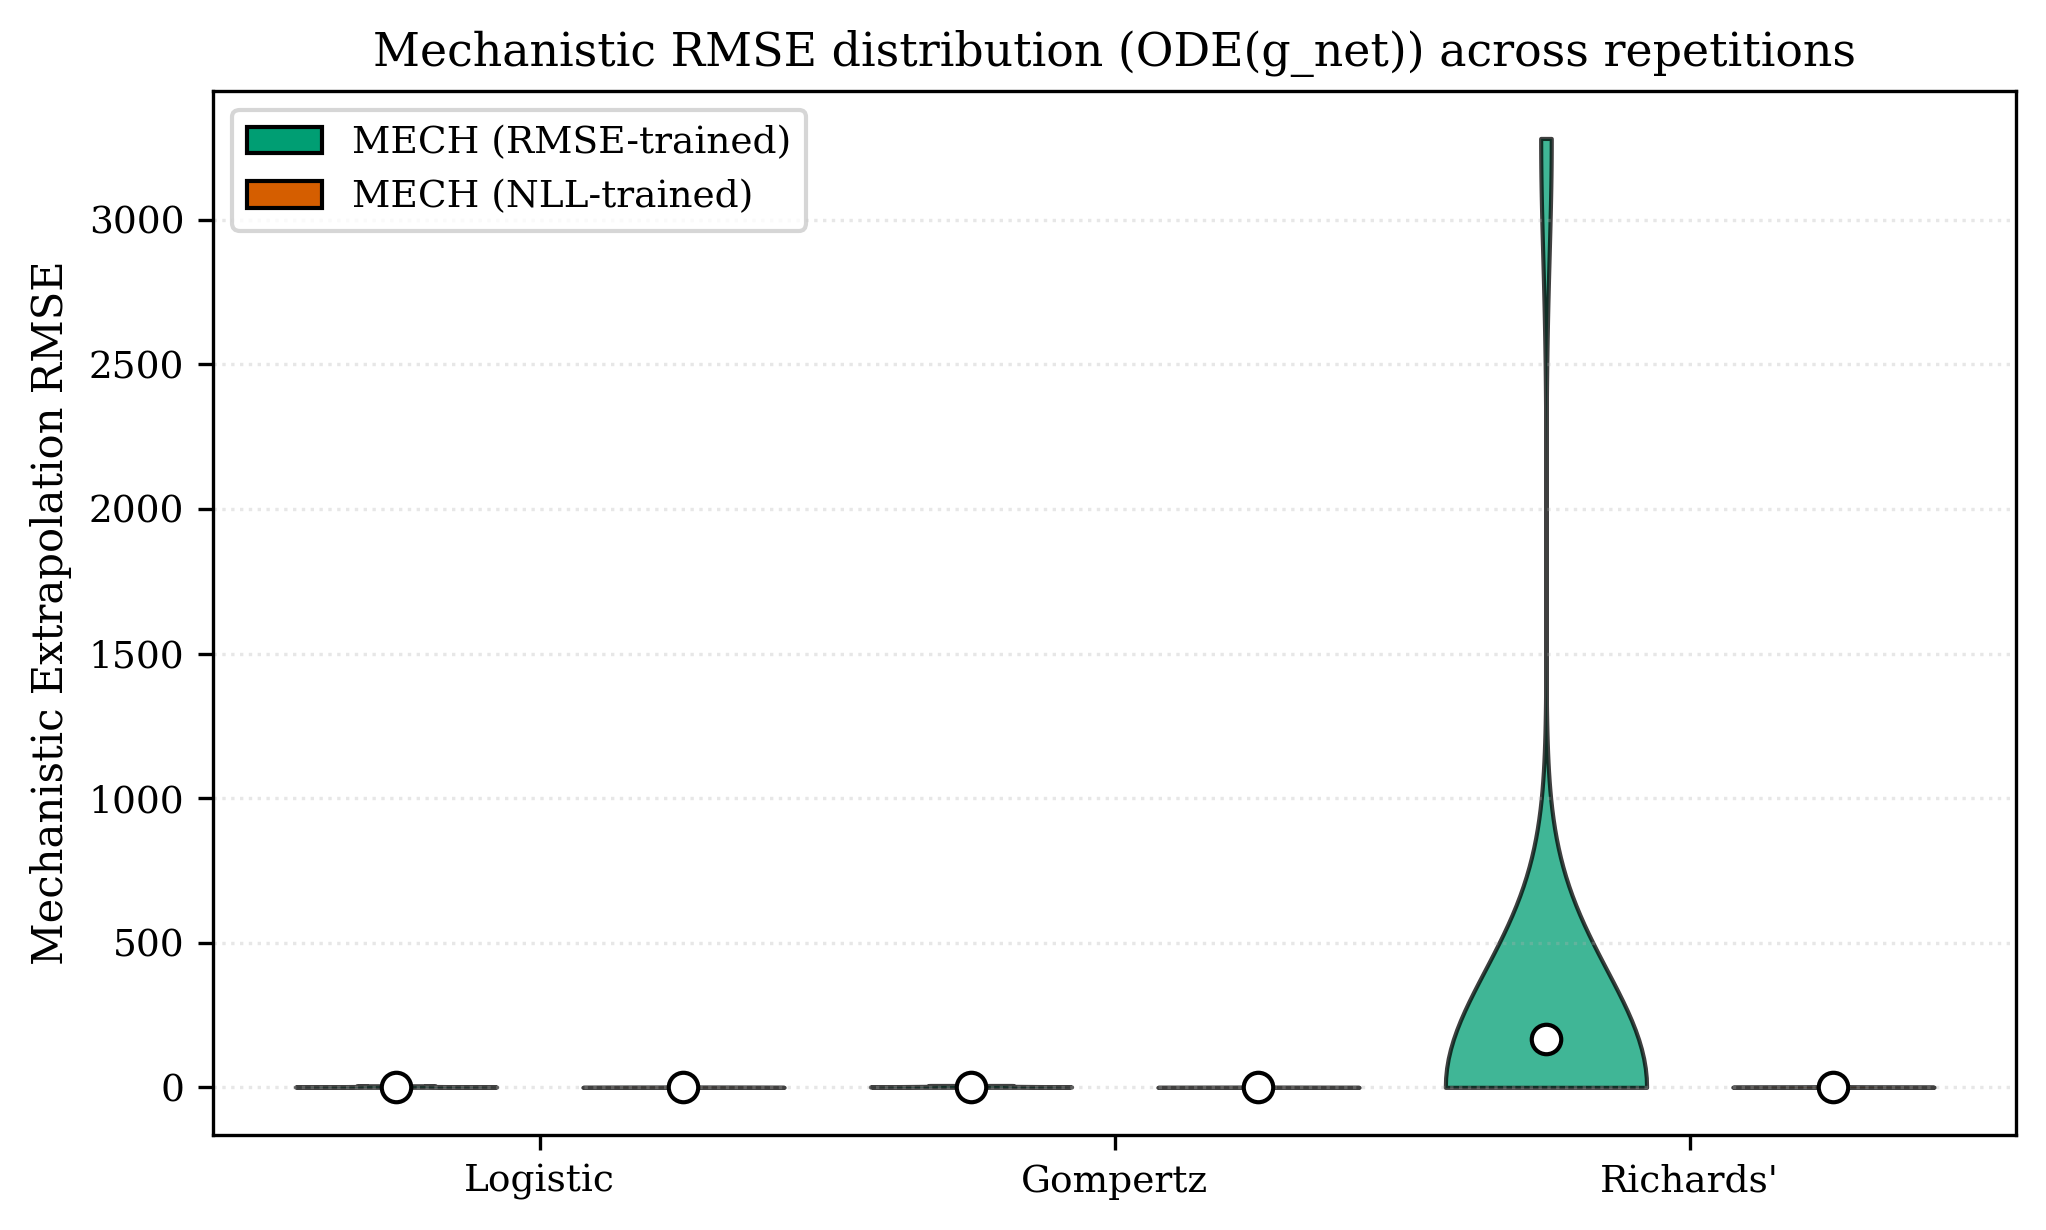

In [66]:
fig, ax = plt.subplots(1, 1)

positions = []
violin_data = []
violin_colors = []

offset = 0.25
for i, label in enumerate(labels_plot):
    md = mech_details[label]

    # RMSE-trained mechanistic RMSEs
    if md["rmses_rmse"] is not None:
        positions.append(i - offset)
        violin_data.append(md["rmses_rmse"])
        violin_colors.append(COLORS["RMSE"])

    # NLL-trained mechanistic RMSEs
    if md["rmses_nll"] is not None:
        positions.append(i + offset)
        violin_data.append(md["rmses_nll"])
        violin_colors.append(COLORS["NLL"])

# Draw violins
parts = ax.violinplot(violin_data, positions=positions, widths=0.35, showmeans=False, showmedians=False, showextrema=False)

# Style violins
for body, col in zip(parts['bodies'], violin_colors):
    body.set_facecolor(col)
    body.set_edgecolor("black")
    body.set_alpha(0.75)

# Overlay mean dots
for pos, data, col in zip(positions, violin_data, violin_colors):
    ax.scatter(pos, np.mean(data), color="white", edgecolor="black", zorder=3, s=50)

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot)
ax.set_ylabel("Mechanistic Extrapolation RMSE")
ax.set_title("Mechanistic RMSE distribution (ODE(g_net)) across repetitions")
ax.grid(axis='y', linestyle=':', alpha=0.3)

# Manual legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=COLORS["RMSE"], edgecolor="black", label="MECH (RMSE-trained)"),
    Patch(facecolor=COLORS["NLL"], edgecolor="black", label="MECH (NLL-trained)"),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

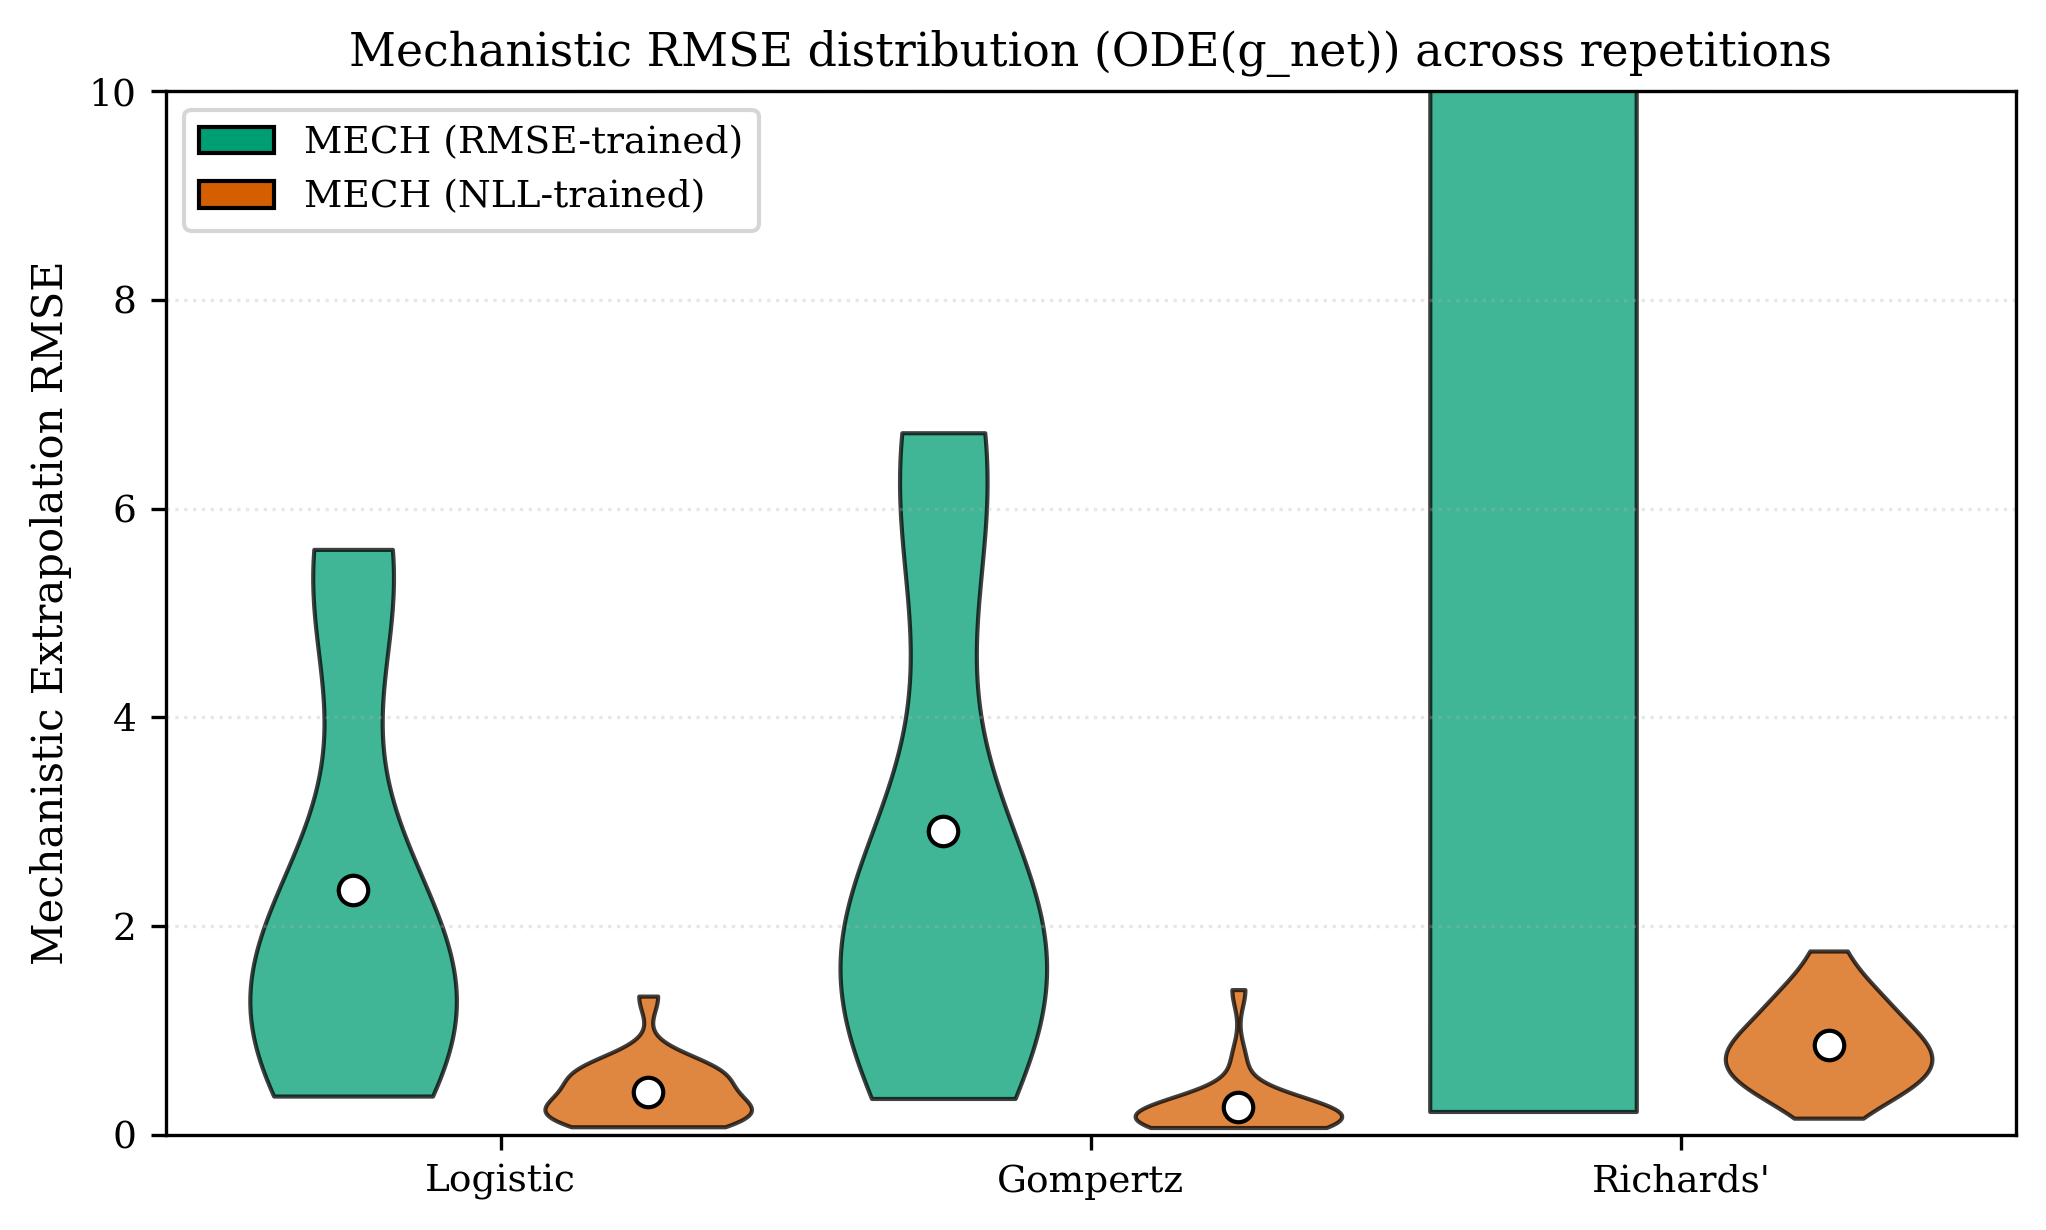

In [67]:
fig, ax = plt.subplots(1, 1)

positions = []
violin_data = []
violin_colors = []

offset = 0.25
for i, label in enumerate(labels_plot):
    md = mech_details[label]

    # RMSE-trained mechanistic RMSEs
    if md["rmses_rmse"] is not None:
        positions.append(i - offset)
        violin_data.append(md["rmses_rmse"])
        violin_colors.append(COLORS["RMSE"])

    # NLL-trained mechanistic RMSEs
    if md["rmses_nll"] is not None:
        positions.append(i + offset)
        violin_data.append(md["rmses_nll"])
        violin_colors.append(COLORS["NLL"])

# Draw violins
parts = ax.violinplot(violin_data, positions=positions, widths=0.35, showmeans=False, showmedians=False, showextrema=False)

# Style violins
for body, col in zip(parts['bodies'], violin_colors):
    body.set_facecolor(col)
    body.set_edgecolor("black")
    body.set_alpha(0.75)

# Overlay mean dots
for pos, data, col in zip(positions, violin_data, violin_colors):
    ax.scatter(pos, np.mean(data), color="white", edgecolor="black", zorder=3, s=50)

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot)
ax.set_ylabel("Mechanistic Extrapolation RMSE")
ax.set_title("Mechanistic RMSE distribution (ODE(g_net)) across repetitions")
ax.grid(axis='y', linestyle=':', alpha=0.3)

# Manual legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=COLORS["RMSE"], edgecolor="black", label="MECH (RMSE-trained)"),
    Patch(facecolor=COLORS["NLL"], edgecolor="black", label="MECH (NLL-trained)"),
]
ax.legend(handles=legend_handles)

ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()

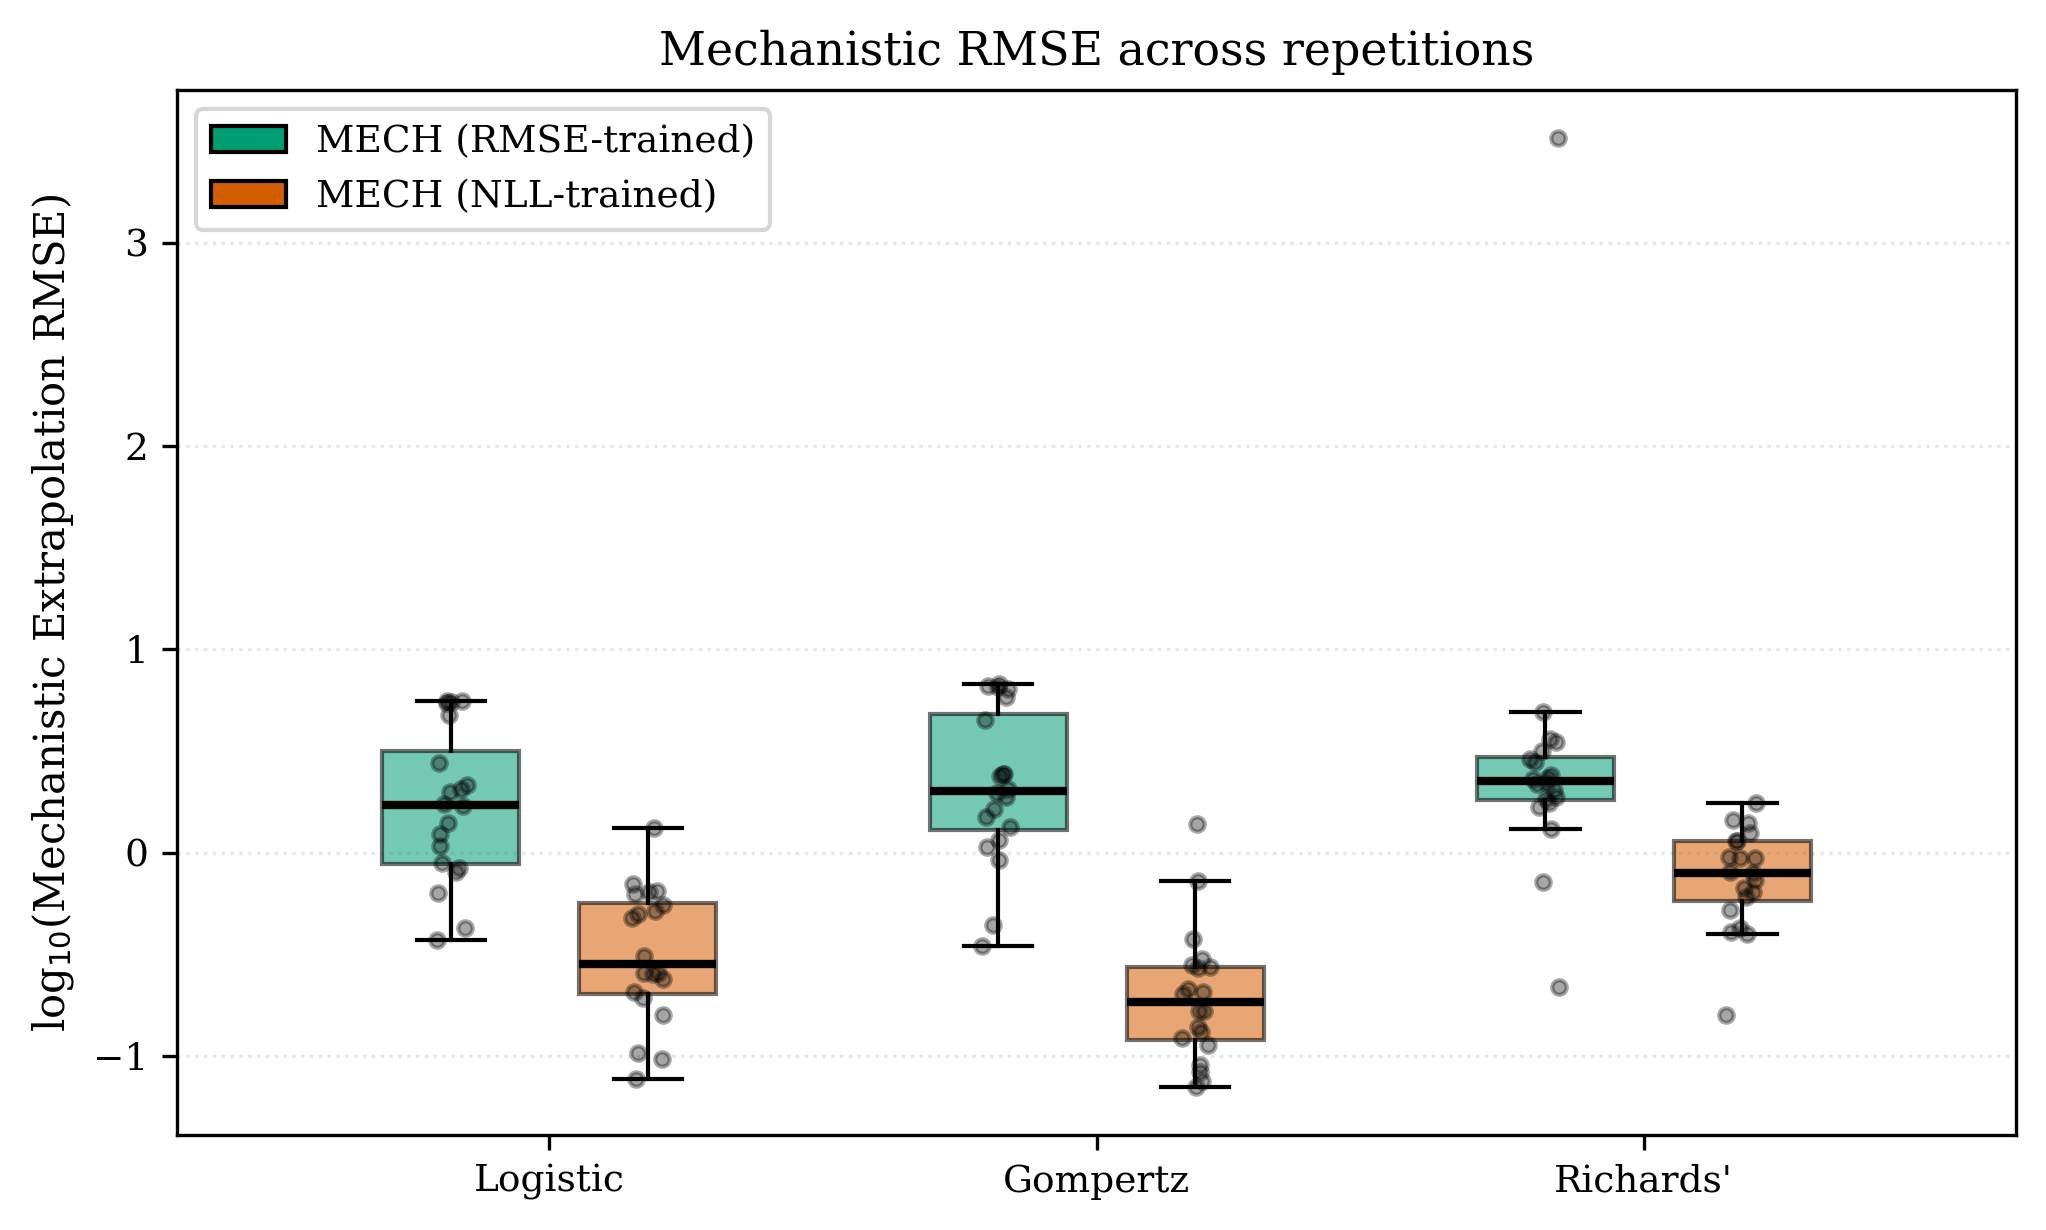

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots()

offset = 0.18

for i, label in enumerate(labels_plot):
    md = mech_details[label]

    groups = []
    if md["rmses_rmse"] is not None:
        groups.append((i - offset, md["rmses_rmse"], COLORS["RMSE"], "RMSE-trained"))
    if md["rmses_nll"] is not None:
        groups.append((i + offset, md["rmses_nll"], COLORS["NLL"], "NLL-trained"))

    for pos, data, col, _ in groups:
        data = np.asarray(data)
        y = np.log10(data)

        # boxplot-like summary
        ax.boxplot(
            y,
            positions=[pos],
            widths=0.25,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor=col, edgecolor="black", alpha=0.55),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
        )

        # individual repetitions
        ax.scatter(
            np.full_like(y, pos, dtype=float) + np.random.uniform(-0.03, 0.03, size=len(y)),
            y,
            s=12,
            color="black",
            alpha=0.35,
            zorder=3,
        )

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot)
ax.set_ylabel(r"log$_{10}$(Mechanistic Extrapolation RMSE)")
ax.set_title("Mechanistic RMSE across repetitions")
ax.grid(axis="y", linestyle=":", alpha=0.3)

legend_handles = [
    Patch(facecolor=COLORS["RMSE"], edgecolor="black", label="MECH (RMSE-trained)"),
    Patch(facecolor=COLORS["NLL"], edgecolor="black", label="MECH (NLL-trained)"),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()